In [1]:
# Pathview-plus examples for paper figures 3.1 and 3.2

#This notebook generates two Pathview-plus example figures for the paper:

#1. Gene-symbol mapping on the human KEGG PI3K-Akt signaling pathway (`hsa04151`)
#2. Multi-condition visualization on the human KEGG MAPK signaling pathway (`hsa04010`)

In [3]:
!pip install pathview-plus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import polars as pl
from IPython.display import Image, display

from pathview import pathview

# Folder where the input tables and figures will be saved
out_dir = Path("pathview_plus_paper_figures")
out_dir.mkdir(exist_ok=True)

print("Output folder:", out_dir.resolve())

Output folder: /content/pathview_plus_paper_figures


In [5]:
def find_outputs(folder, keyword):
    """Find files generated by Pathview-plus that contain the keyword."""
    files = []
    for pattern in [f"*{keyword}*.png", f"*{keyword}*.svg", f"*{keyword}*.pdf"]:
        files.extend(folder.glob(pattern))
    return sorted(files, key=lambda p: p.stat().st_mtime, reverse=True)


def show_png(folder, keyword):
    """Display the newest matching PNG output."""
    files = find_outputs(folder, keyword)

    print("Matching files:")
    for f in files:
        print("-", f)

    pngs = [f for f in files if f.suffix.lower() == ".png"]

    if pngs:
        display(Image(filename=str(pngs[0])))
    else:
        print("No PNG found. Check the output folder.")

## Figure 3.1: Gene-symbol mapping on KEGG PI3K-Akt signaling

This example maps gene symbols and example log fold-change values onto the human KEGG PI3K-Akt signaling pathway.

Pathway: `hsa04151`  
Input type: gene symbols  
Purpose: show identifier mapping and pathway coloring

In [6]:
gene_symbol_data = pl.DataFrame({
    "symbol": ["TP53", "EGFR", "KRAS", "PIK3CA", "AKT1"],
    "log2fc": [-1.8, 2.4, 1.1, 1.5, 0.9],
})

gene_symbol_data

symbol,log2fc
str,f64
"""TP53""",-1.8
"""EGFR""",2.4
"""KRAS""",1.1
"""PIK3CA""",1.5
"""AKT1""",0.9


In [7]:
gene_symbol_input_path = out_dir / "figure_3_1_gene_symbol_pik3akt_input.tsv"

gene_symbol_data.write_csv(
    gene_symbol_input_path,
    separator="\t"
)

print("Saved:", gene_symbol_input_path)

Saved: pathview_plus_paper_figures/figure_3_1_gene_symbol_pik3akt_input.tsv


In [9]:
# Temporary patch:
# Pathview-plus is trying to fetch the KEGG organism list and KEGG is returning 400.
# Since we already know hsa = Homo sapiens, this skips that lookup.

import importlib
from pathview.kegg_api import SpeciesInfo

pv_module = importlib.import_module("pathview.pathview")

def local_kegg_species_code(species="hsa"):
    if species == "hsa":
        return SpeciesInfo(
            kegg_code="hsa",
            entrez_gnodes=True,
            kegg_geneid=None,
            ncbi_geneid=None,
            ncbi_proteinid=None,
            uniprot=None,
        )

    if species == "ko":
        return SpeciesInfo(
            kegg_code="ko",
            entrez_gnodes=False,
            kegg_geneid="K01488",
            ncbi_geneid=None,
            ncbi_proteinid=None,
            uniprot=None,
        )

    raise ValueError(f"This temporary patch only handles hsa or ko, not {species}")

pv_module.kegg_species_code = local_kegg_species_code

print("Patched Pathview-plus species lookup for hsa.")

Patched Pathview-plus species lookup for hsa.


In [10]:
fig_31_result = pathview(
    pathway_id="04151",      # PI3K-Akt signaling pathway
    gene_data=gene_symbol_data,
    species="hsa",
    gene_idtype="SYMBOL",
    kegg_dir=out_dir,
    output_format="png",
    out_suffix="figure_3_1_gene_symbol_pik3akt",
    limit={"gene": 2.5, "cpd": 1.5},
    low={"gene": "#2166AC", "cpd": "#4575B4"},
    mid={"gene": "#F7F7F7", "cpd": "#F7F7F7"},
    high={"gene": "#D6604D", "cpd": "#B2182B"},
    new_signature=False,
)

fig_31_result

/usr/local/lib/python3.12/dist-packages/pathview/id_mapping.py:57: UserWarning: MyGene.info query failed: 404 Client Error: Not Found for url: https://mygene.info/v3/querymany
  warnings.warn(f"MyGene.info query failed: {exc}")


Info: Downloading xml for hsa04151 …
Info: Downloading png for hsa04151 …
Info: Written → pathview_plus_paper_figures/hsa04151.figure_3_1_gene_symbol_pik3akt.png


{'plot_data_gene': None,
 'plot_data_cpd': shape: (5, 10)
 ┌──────────┬────────────┬───────┬───────┬───┬────────┬──────────┬──────┬─────────┐
 │ entry_id ┆ kegg_names ┆ x     ┆ y     ┆ … ┆ label  ┆ type     ┆ size ┆ mol_val │
 │ ---      ┆ ---        ┆ ---   ┆ ---   ┆   ┆ ---    ┆ ---      ┆ ---  ┆ ---     │
 │ str      ┆ str        ┆ f64   ┆ f64   ┆   ┆ str    ┆ str      ┆ i64  ┆ f64     │
 ╞══════════╪════════════╪═══════╪═══════╪═══╪════════╪══════════╪══════╪═════════╡
 │ 159      ┆ C05981     ┆ 489.0 ┆ 780.0 ┆ … ┆ C05981 ┆ compound ┆ 1    ┆ NaN     │
 │ 249      ┆ C00020     ┆ 563.0 ┆ 90.0  ┆ … ┆ C00020 ┆ compound ┆ 1    ┆ NaN     │
 │ 116      ┆ C00533     ┆ 810.0 ┆ 274.0 ┆ … ┆ C00533 ┆ compound ┆ 1    ┆ NaN     │
 │ 5        ┆ C05981     ┆ 423.0 ┆ 568.0 ┆ … ┆ C05981 ┆ compound ┆ 1    ┆ NaN     │
 │ 158      ┆ C04637     ┆ 363.0 ┆ 776.0 ┆ … ┆ C04637 ┆ compound ┆ 1    ┆ NaN     │
 └──────────┴────────────┴───────┴───────┴───┴────────┴──────────┴──────┴─────────┘}

Matching files:
- pathview_plus_paper_figures/hsa04151.figure_3_1_gene_symbol_pik3akt.png


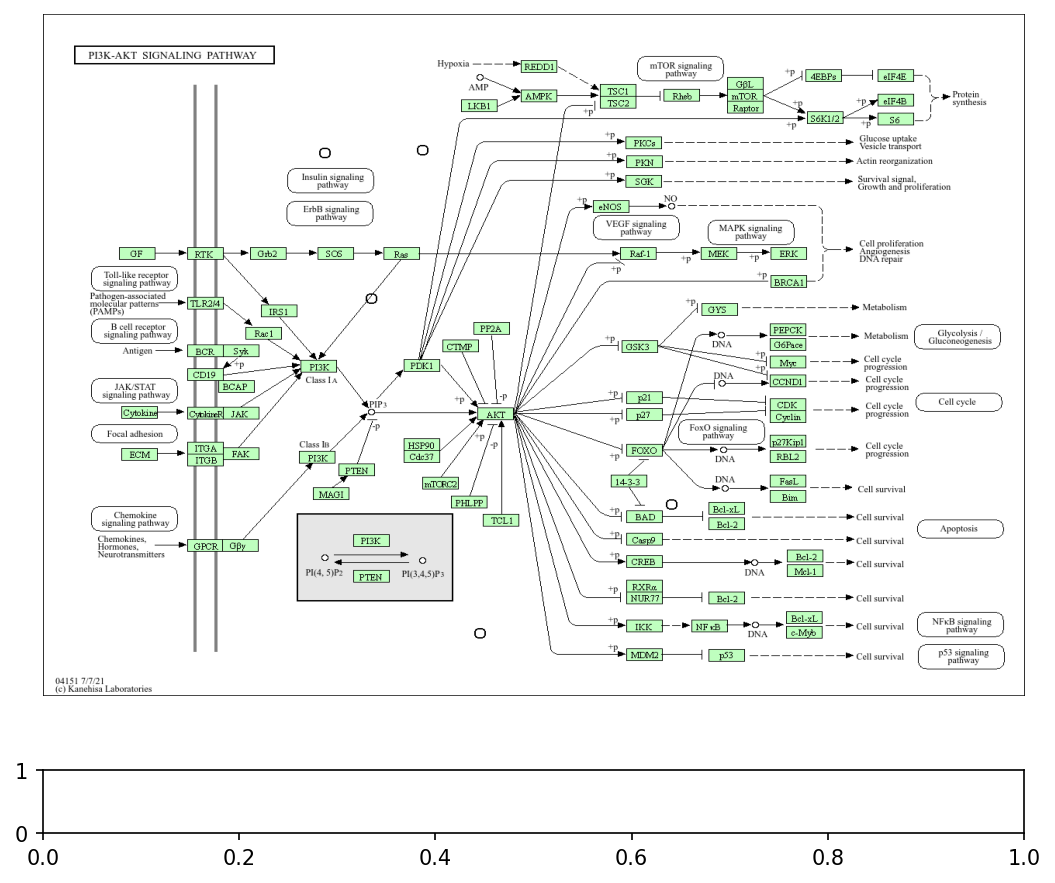

In [11]:
show_png(out_dir, "figure_3_1_gene_symbol_pik3akt")

In [13]:
gene_symbol_fallback_data = pl.DataFrame({
    "entrez": ["7157", "1956", "3845", "5290", "207"],
    "log2fc": [-1.8, 2.4, 1.1, 1.5, 0.9],
})

gene_symbol_fallback_data

entrez,log2fc
str,f64
"""7157""",-1.8
"""1956""",2.4
"""3845""",1.1
"""5290""",1.5
"""207""",0.9


In [14]:
fig_31_result = pathview(
    pathway_id="04151",
    gene_data=gene_symbol_fallback_data,
    species="hsa",
    gene_idtype="ENTREZ",
    kegg_dir=out_dir,
    output_format="png",
    out_suffix="figure_3_1_gene_symbol_pik3akt_fallback_entrez",
    limit={"gene": 2.5, "cpd": 1.5},
    low={"gene": "#2166AC", "cpd": "#4575B4"},
    mid={"gene": "#F7F7F7", "cpd": "#F7F7F7"},
    high={"gene": "#D6604D", "cpd": "#B2182B"},
    new_signature=False,
)

fig_31_result

/usr/local/lib/python3.12/dist-packages/pathview/pathview.py:315: UserWarning: Symbol label mapping failed: "kegg_names" not found
  warnings.warn(f"Symbol label mapping failed: {exc}")


Info: Written → pathview_plus_paper_figures/hsa04151.figure_3_1_gene_symbol_pik3akt_fallback_entrez.png


{'plot_data_gene': shape: (90, 14)
 ┌──────────┬────────────────────────────┬──────┬────────┬───┬──────────┬───────────┬──────┬────────┐
 │ entry_id ┆ name                       ┆ type ┆ x      ┆ … ┆ reaction ┆ component ┆ size ┆ log2fc │
 │ ---      ┆ ---                        ┆ ---  ┆ ---    ┆   ┆ ---      ┆ ---       ┆ ---  ┆ ---    │
 │ str      ┆ str                        ┆ str  ┆ f64    ┆   ┆ str      ┆ str       ┆ i64  ┆ f64    │
 ╞══════════╪════════════════════════════╪══════╪════════╪═══╪══════════╪═══════════╪══════╪════════╡
 │ 6        ┆ hsa:1977 hsa:253314        ┆ gene ┆ 1099.0 ┆ … ┆          ┆           ┆ 1    ┆ null   │
 │          ┆ hsa:9470                   ┆      ┆        ┆   ┆          ┆           ┆      ┆        │
 │ 7        ┆ hsa:1978                   ┆ gene ┆ 1006.0 ┆ … ┆          ┆           ┆ 1    ┆ null   │
 │ 8        ┆ hsa:6194                   ┆ gene ┆ 1099.0 ┆ … ┆          ┆           ┆ 1    ┆ null   │
 │ 9        ┆ hsa:1975                   ┆ gene

Matching files:
- pathview_plus_paper_figures/hsa04151.figure_3_1_gene_symbol_pik3akt_fallback_entrez.png


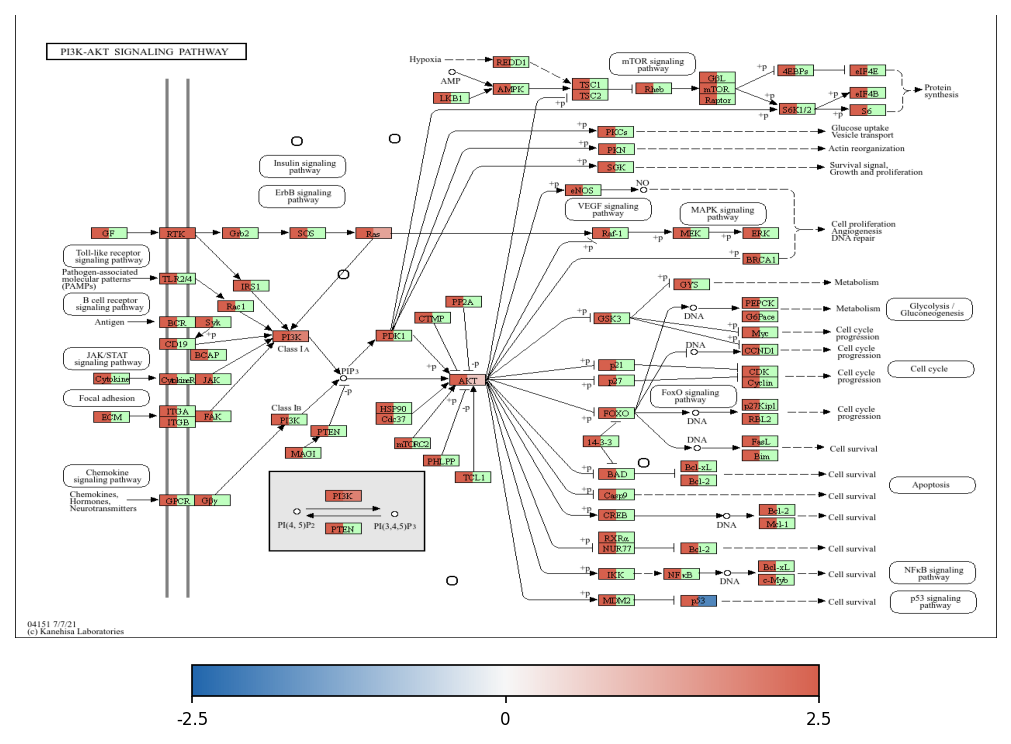

In [15]:
show_png(out_dir, "figure_3_1_gene_symbol_pik3akt_fallback_entrez")

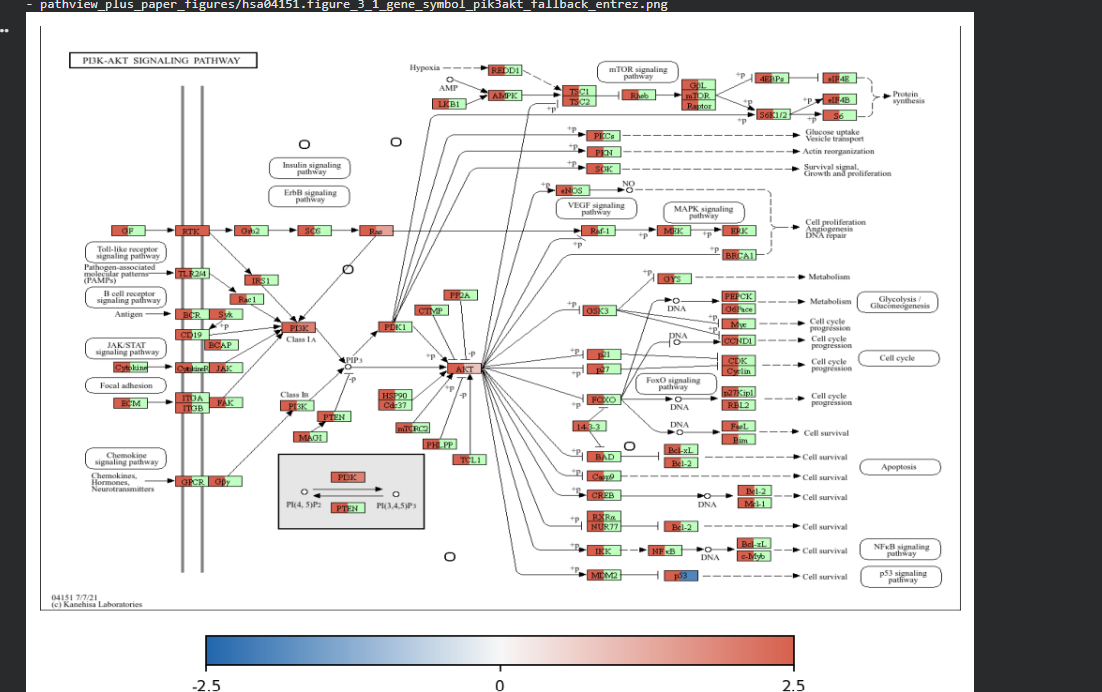

## Figure 3.2: Multi-condition visualization on KEGG MAPK signaling

This example demonstrates how Pathview-plus can visualize multiple experimental
conditions on a single KEGG pathway.

Pathway: hsa04010 (MAPK signaling)

Conditions:
- Control
- Treatment_A
- Treatment_B

The values below are demonstration values included to illustrate the
multi-condition workflow.

In [17]:
multi_condition_data = pl.DataFrame({
    "entrez": ["1956", "2099", "5594", "207"],
    "Control": [0.5, -0.3, 1.2, -0.8],
    "Treatment_A": [2.1, -1.5, 0.4, 1.3],
    "Treatment_B": [1.8, -0.9, 2.3, 0.7],
})

multi_condition_data

entrez,Control,Treatment_A,Treatment_B
str,f64,f64,f64
"""1956""",0.5,2.1,1.8
"""2099""",-0.3,-1.5,-0.9
"""5594""",1.2,0.4,2.3
"""207""",-0.8,1.3,0.7


In [18]:
multi_condition_input_path = (
    out_dir / "figure_3_2_multi_condition_mapk_input.tsv"
)

multi_condition_data.write_csv(
    multi_condition_input_path,
    separator="\t"
)

print(multi_condition_input_path)

pathview_plus_paper_figures/figure_3_2_multi_condition_mapk_input.tsv


In [19]:
fig_32_result = pathview(
    pathway_id="04010",
    gene_data=multi_condition_data,
    species="hsa",
    gene_idtype="ENTREZ",
    kegg_dir=out_dir,
    output_format="png",
    out_suffix="figure_3_2_multi_condition_mapk",
    limit={"gene": 2.5, "cpd": 1.5},
    low={"gene": "#2166AC", "cpd": "#4575B4"},
    mid={"gene": "#F7F7F7", "cpd": "#F7F7F7"},
    high={"gene": "#D6604D", "cpd": "#B2182B"},
    new_signature=False,
)

fig_32_result

Info: Downloading xml for hsa04010 …
Info: Downloading png for hsa04010 …
Note: 1 of 4 input IDs unmapped.


/usr/local/lib/python3.12/dist-packages/pathview/pathview.py:315: UserWarning: Symbol label mapping failed: "kegg_names" not found
  warnings.warn(f"Symbol label mapping failed: {exc}")


Info: Written → pathview_plus_paper_figures/hsa04010.figure_3_2_multi_condition_mapk.png


{'plot_data_gene': shape: (120, 16)
 ┌──────────┬────────────────────┬──────┬───────┬───┬──────┬─────────┬─────────────┬─────────────┐
 │ entry_id ┆ name               ┆ type ┆ x     ┆ … ┆ size ┆ Control ┆ Treatment_A ┆ Treatment_B │
 │ ---      ┆ ---                ┆ ---  ┆ ---   ┆   ┆ ---  ┆ ---     ┆ ---         ┆ ---         │
 │ str      ┆ str                ┆ str  ┆ f64   ┆   ┆ i64  ┆ f64     ┆ f64         ┆ f64         │
 ╞══════════╪════════════════════╪══════╪═══════╪═══╪══════╪═════════╪═════════════╪═════════════╡
 │ 20       ┆ hsa:5923 hsa:5924  ┆ gene ┆ 392.0 ┆ … ┆ 1    ┆ null    ┆ null        ┆ null        │
 │ 21       ┆ hsa:11221 hsa:1843 ┆ gene ┆ 789.0 ┆ … ┆ 1    ┆ null    ┆ null        ┆ null        │
 │          ┆ hsa:1844 hs…       ┆      ┆       ┆   ┆      ┆         ┆             ┆             │
 │ 22       ┆ hsa:1845 hsa:5778  ┆ gene ┆ 740.0 ┆ … ┆ 1    ┆ null    ┆ null        ┆ null        │
 │          ┆ hsa:5801 hsa…      ┆      ┆       ┆   ┆      ┆         ┆   

Matching files:
- pathview_plus_paper_figures/hsa04010.figure_3_2_multi_condition_mapk.png


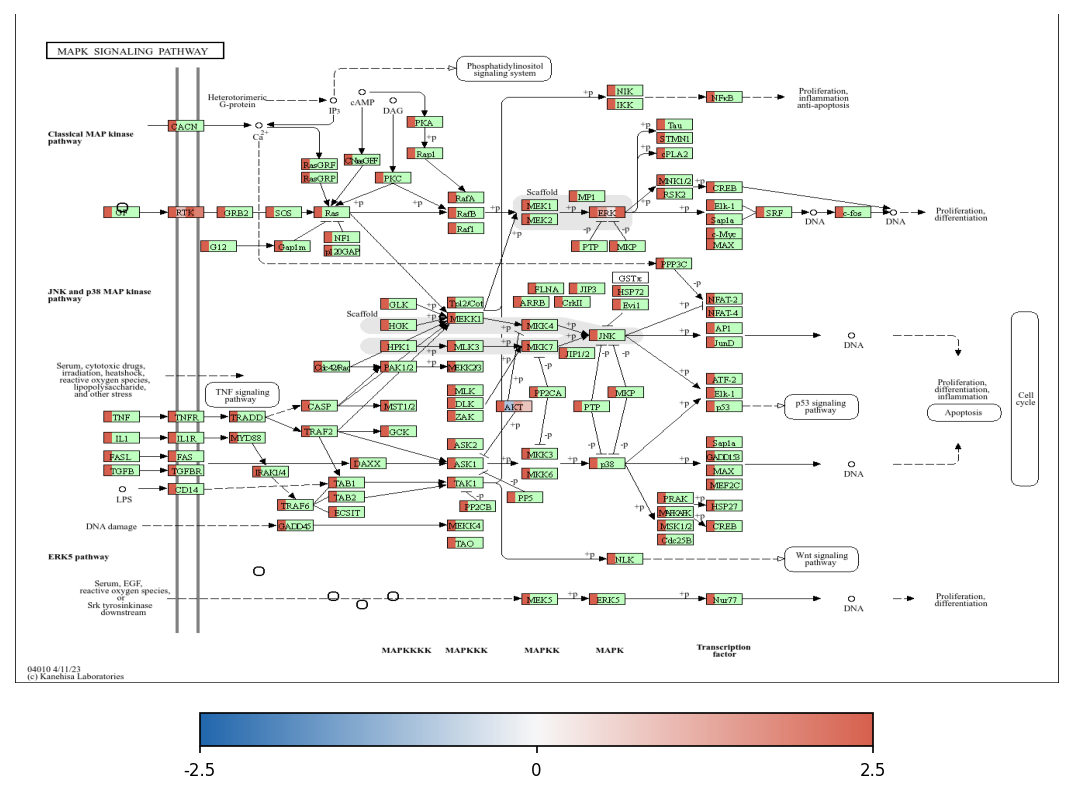

In [20]:
show_png(out_dir, "figure_3_2_multi_condition_mapk")